In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

dados = pd.read_json(url)

dados.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [2]:
dados.shape

(7267, 6)

In [3]:
dados.columns

Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')

In [4]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [5]:
dados.iloc[0]

,0
customerID,0002-ORFBO
Churn,No
customer,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part..."
phone,"{'PhoneService': 'Yes', 'MultipleLines': 'No'}"
internet,"{'InternetService': 'DSL', 'OnlineSecurity': '..."
account,"{'Contract': 'One year', 'PaperlessBilling': '..."


In [7]:
import requests
import pandas as pd

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

response = requests.get(url)
data = response.json()

df = pd.json_normalize(data)

df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [8]:
df.describe()

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly
count,7267.000000,7267.000000,7267.000000
mean,0.162653,32.346498,64.720098
std,0.369074,24.571773,30.129572
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.425000
50%,0.000000,29.000000,70.300000
75%,0.000000,55.000000,89.875000
max,1.000000,72.000000,118.750000


In [9]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [11]:
customer = pd.json_normalize(dados["customer"])
phone = pd.json_normalize(dados["phone"])
internet = pd.json_normalize(dados["internet"])
account = pd.json_normalize(dados["account"])

In [12]:
df_final = pd.concat(
    [dados[["customerID", "Churn"]], customer, phone, internet, account],
    axis=1
)

df_final.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [13]:
df_final.columns

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly',
       'Charges.Total'],
      dtype='object')

In [14]:
df_final.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [15]:
df_final.duplicated().sum()

np.int64(0)

In [16]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [17]:
dados.columns

Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')

In [19]:
df.columns = df.columns.str.strip()

In [21]:
df.columns

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

In [22]:
df["account.Charges.Total"] = pd.to_numeric(
    df["account.Charges.Total"], errors="coerce"
)

In [23]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [24]:
df = df.dropna()

In [25]:
df = df.rename(columns={
    "customer.gender": "gender",
    "customer.SeniorCitizen": "SeniorCitizen",
    "customer.Partner": "Partner",
    "customer.Dependents": "Dependents",
    "customer.tenure": "tenure",
    "phone.PhoneService": "PhoneService",
    "phone.MultipleLines": "MultipleLines",
    "internet.InternetService": "InternetService",
    "internet.OnlineSecurity": "OnlineSecurity",
    "internet.OnlineBackup": "OnlineBackup",
    "internet.DeviceProtection": "DeviceProtection",
    "internet.TechSupport": "TechSupport",
    "internet.StreamingTV": "StreamingTV",
    "internet.StreamingMovies": "StreamingMovies",
    "account.Contract": "Contract",
    "account.PaperlessBilling": "PaperlessBilling",
    "account.PaymentMethod": "PaymentMethod",
    "account.Charges.Monthly": "MonthlyCharges",
    "account.Charges.Total": "TotalCharges"
})

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7256 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7256 non-null   object 
 1   Churn             7256 non-null   object 
 2   gender            7256 non-null   object 
 3   SeniorCitizen     7256 non-null   int64  
 4   Partner           7256 non-null   object 
 5   Dependents        7256 non-null   object 
 6   tenure            7256 non-null   int64  
 7   PhoneService      7256 non-null   object 
 8   MultipleLines     7256 non-null   object 
 9   InternetService   7256 non-null   object 
 10  OnlineSecurity    7256 non-null   object 
 11  OnlineBackup      7256 non-null   object 
 12  DeviceProtection  7256 non-null   object 
 13  TechSupport       7256 non-null   object 
 14  StreamingTV       7256 non-null   object 
 15  StreamingMovies   7256 non-null   object 
 16  Contract          7256 non-null   object 
 17  

In [27]:
df.duplicated().sum()

np.int64(0)

In [28]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7256.0000,7256.000000,7256.000000,7256.000000
mean,0.1629,32.395535,64.755423,2280.634213
std,0.3693,24.558067,30.125739,2268.632997
min,0.0000,1.000000,18.250000,18.800000
25%,0.0000,9.000000,35.450000,400.225000
50%,0.0000,29.000000,70.300000,1391.000000
75%,0.0000,55.000000,89.900000,3785.300000
max,1.0000,72.000000,118.750000,8684.800000


In [30]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [31]:
df.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [32]:
df = df.dropna()

In [33]:
df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

In [34]:
df["Contas_Diarias"] = df["MonthlyCharges"] / 30

In [35]:
df[["MonthlyCharges", "Contas_Diarias"]].head()

,MonthlyCharges,Contas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


In [36]:
df["Contas_Diarias"].describe()

,Contas_Diarias
count,7256.000000
mean,2.158514
std,1.004191
min,0.608333
25%,1.181667
50%,2.343333
75%,2.996667
max,3.958333


In [37]:
binarias = [
    "Partner","Dependents","PhoneService","PaperlessBilling",
    "OnlineSecurity","OnlineBackup","DeviceProtection",
    "TechSupport","StreamingTV","StreamingMovies","MultipleLines"
]

for col in binarias:
    df[col] = df[col].map({"Yes":1, "No":0})

In [38]:
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

In [39]:
df["gender"] = df["gender"].map({
    "Male":"Masculino",
    "Female":"Feminino"
})

In [40]:
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Contas_Diarias
0,0002-ORFBO,NaN,Feminino,0,1,1,9,1,0.0,DSL,...,0.0,1.0,1.0,0.0,One year,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,NaN,Masculino,0,0,0,9,1,1.0,DSL,...,0.0,0.0,0.0,1.0,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,NaN,Masculino,0,0,0,4,1,0.0,Fiber optic,...,1.0,0.0,0.0,0.0,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,NaN,Masculino,1,1,0,13,1,0.0,Fiber optic,...,1.0,0.0,1.0,1.0,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,NaN,Feminino,1,1,0,3,1,0.0,Fiber optic,...,0.0,1.0,1.0,0.0,Month-to-month,1,Mailed check,83.9,267.40,2.796667


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7256 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7256 non-null   object 
 1   Churn             0 non-null      float64
 2   gender            7256 non-null   object 
 3   SeniorCitizen     7256 non-null   int64  
 4   Partner           7256 non-null   int64  
 5   Dependents        7256 non-null   int64  
 6   tenure            7256 non-null   int64  
 7   PhoneService      7256 non-null   int64  
 8   MultipleLines     6551 non-null   float64
 9   InternetService   7256 non-null   object 
 10  OnlineSecurity    5681 non-null   float64
 11  OnlineBackup      5681 non-null   float64
 12  DeviceProtection  5681 non-null   float64
 13  TechSupport       5681 non-null   float64
 14  StreamingTV       5681 non-null   float64
 15  StreamingMovies   5681 non-null   float64
 16  Contract          7256 non-null   object 
 17  

In [43]:
df["Churn"].dtype

dtype('float64')

In [44]:
df["Churn"].value_counts(dropna=False)

,count
Churn,
NaN,7256


In [45]:
df["Churn"].unique()

array([nan])

In [46]:
import pandas as pd

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

df = pd.read_json(url)

In [47]:
df = pd.json_normalize(df.to_dict(orient="records"))

In [48]:
df["Churn"].unique()

array(['No', 'Yes', ''], dtype=object)

In [49]:
df["Churn"] = df["Churn"].astype(str).str.strip().str.lower()

In [50]:
df["Churn"] = df["Churn"].map({
    "yes": 1,
    "no": 0
})


In [51]:
df["Churn"].value_counts()

,count
Churn,
0.0,5174
1.0,1869


In [52]:
df.describe()

,Churn,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly
count,7043.000000,7267.000000,7267.000000,7267.000000
mean,0.265370,0.162653,32.346498,64.720098
std,0.441561,0.369074,24.571773,30.129572
min,0.000000,0.000000,0.000000,18.250000
25%,0.000000,0.000000,9.000000,35.425000
50%,0.000000,0.000000,29.000000,70.300000
75%,1.000000,0.000000,55.000000,89.875000
max,1.000000,1.000000,72.000000,118.750000


In [54]:
df.groupby("Churn")[[
    "customer.tenure",
    "account.Charges.Monthly",
    "account.Charges.Total"
]].mean()

TypeError: agg function failed [how->mean,dtype->object]

In [55]:
df["account.Charges.Total"] = pd.to_numeric(
    df["account.Charges.Total"], errors="coerce"
)

In [56]:
df[["account.Charges.Total"]].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 1 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   account.Charges.Total  7256 non-null   float64
dtypes: float64(1)
memory usage: 56.9 KB


In [57]:
df.groupby("Churn")[[
    "customer.tenure",
    "account.Charges.Monthly",
    "account.Charges.Total"
]].mean()

,customer.tenure,account.Charges.Monthly,account.Charges.Total
Churn,,,
0.0,37.569965,61.265124,2555.344141
1.0,17.979133,74.441332,1531.796094


In [58]:
df["Churn"].value_counts()

,count
Churn,
0.0,5174
1.0,1869


In [59]:
df["Churn"].value_counts(normalize=True)

,proportion
Churn,
0.0,0.73463
1.0,0.26537


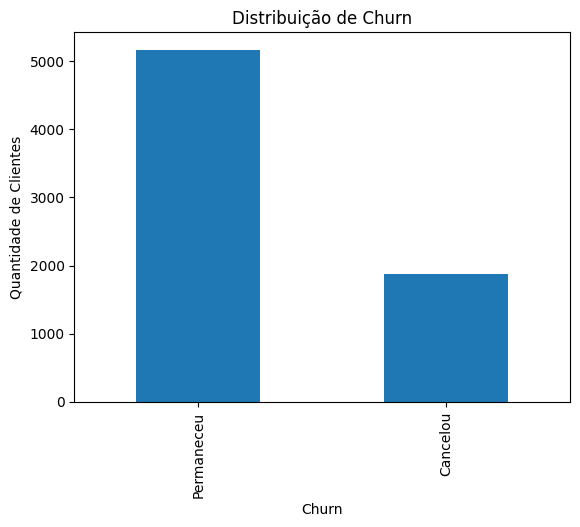

In [60]:
import matplotlib.pyplot as plt

df["Churn"].value_counts().plot(kind="bar")

plt.title("Distribuição de Churn")
plt.xlabel("Churn")
plt.ylabel("Quantidade de Clientes")
plt.xticks([0,1], ["Permaneceu","Cancelou"])
plt.show()

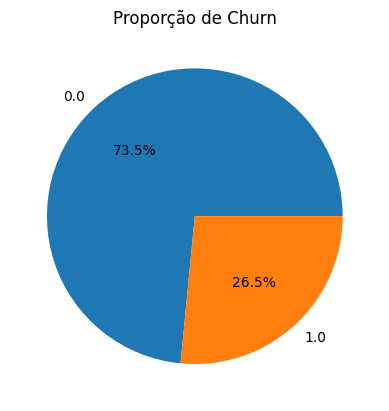

In [61]:
df["Churn"].value_counts().plot(kind="pie", autopct="%1.1f%%")

plt.title("Proporção de Churn")
plt.ylabel("")
plt.show()

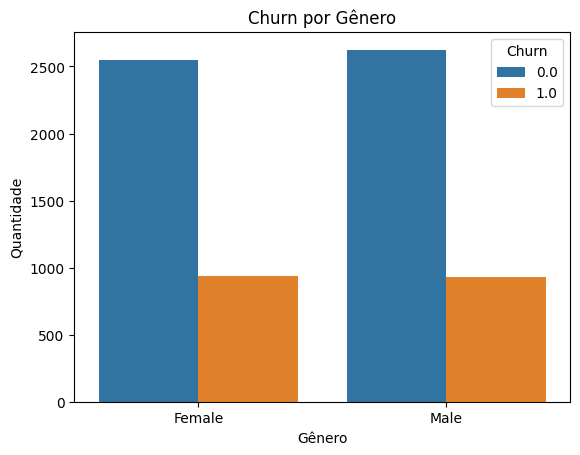

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="customer.gender", hue="Churn", data=df)

plt.title("Churn por Gênero")
plt.xlabel("Gênero")
plt.ylabel("Quantidade")
plt.show()

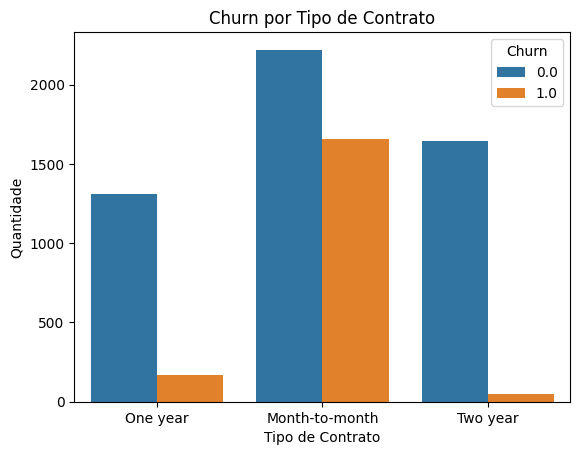

In [63]:
sns.countplot(x="account.Contract", hue="Churn", data=df)

plt.title("Churn por Tipo de Contrato")
plt.xlabel("Tipo de Contrato")
plt.ylabel("Quantidade")
plt.show()

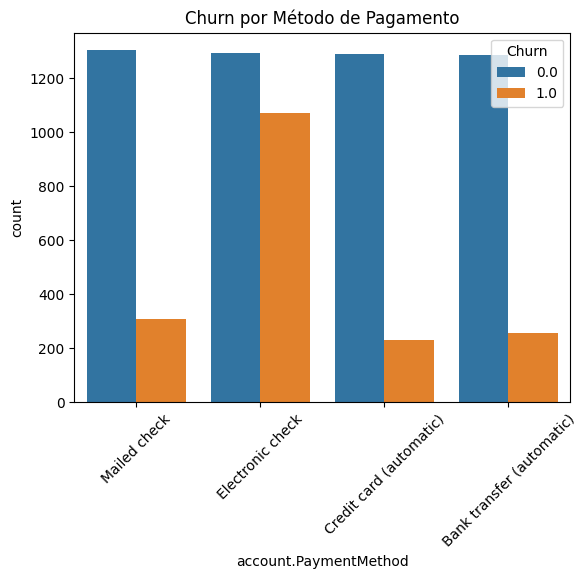

In [64]:
sns.countplot(x="account.PaymentMethod", hue="Churn", data=df)

plt.title("Churn por Método de Pagamento")
plt.xticks(rotation=45)
plt.show()

In [65]:
pd.crosstab(
    df["account.Contract"],
    df["Churn"],
    normalize="index"
)

Churn,0.0,1.0
account.Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


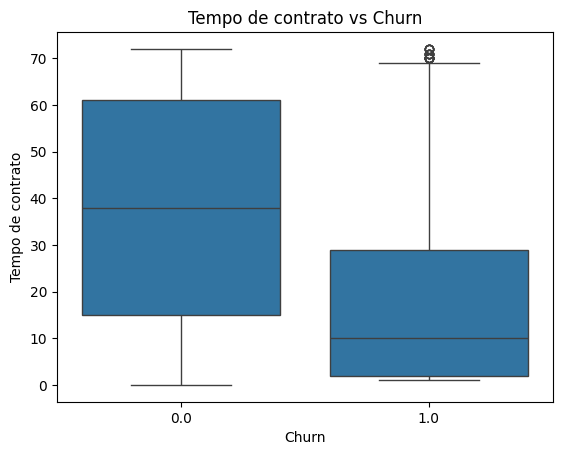

In [66]:
sns.boxplot(x="Churn", y="customer.tenure", data=df)

plt.title("Tempo de contrato vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tempo de contrato")
plt.show()

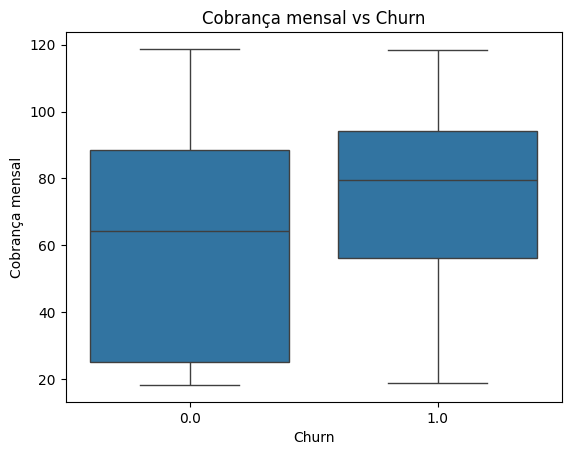

In [67]:
sns.boxplot(x="Churn", y="account.Charges.Monthly", data=df)

plt.title("Cobrança mensal vs Churn")
plt.xlabel("Churn")
plt.ylabel("Cobrança mensal")
plt.show()

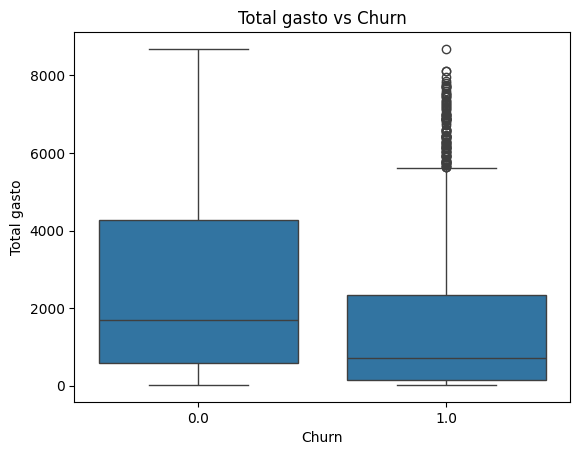

In [68]:
sns.boxplot(x="Churn", y="account.Charges.Total", data=df)

plt.title("Total gasto vs Churn")
plt.xlabel("Churn")
plt.ylabel("Total gasto")
plt.show()

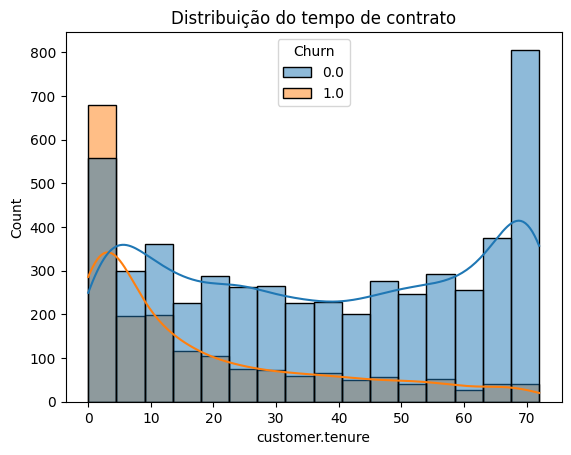

In [69]:
sns.histplot(data=df, x="customer.tenure", hue="Churn", kde=True)
plt.title("Distribuição do tempo de contrato")
plt.show()

#📄Relatorio Final

Introdução

O objetivo desta análise é entender melhor o problema de evasão de clientes (churn). O churn acontece quando um cliente decide cancelar um serviço. Para empresas que trabalham com assinaturas, isso é um problema importante, pois a perda de clientes pode afetar diretamente a receita.

Nesta atividade, a proposta é analisar os dados de clientes para identificar possíveis padrões que expliquem por que alguns clientes cancelam o serviço enquanto outros continuam utilizando.

Limpeza e Tratamento de Dados

Antes de iniciar a análise, foi necessário preparar os dados. Primeiro, os dados foram importados para o notebook utilizando a biblioteca pandas.

Depois disso, foram feitas algumas verificações para entender melhor o conjunto de dados, como o uso das funções head() e info().

Durante essa etapa também foram realizadas algumas correções, como:

- verificação de valores ausentes;

- conversão de algumas colunas para o formato numérico, como a coluna de Total Charges;

- tratamento da coluna Churn, transformando os valores em formato numérico para facilitar a análise.

Esses passos foram importantes para garantir que os dados estivessem organizados e prontos para análise.

Análise Exploratória de Dados

Na análise exploratória foram utilizados gráficos e algumas estatísticas para entender melhor o comportamento dos clientes.

Primeiro foi analisada a distribuição da variável Churn, que indica se o cliente cancelou ou não o serviço. Foi possível observar que a maioria dos clientes continua utilizando o serviço, enquanto uma parte menor realizou o cancelamento.

Depois foram analisadas algumas variáveis categóricas, como:

- gênero

- tipo de contrato

- método de pagamento

Os gráficos mostraram que clientes com contratos mensais parecem ter uma tendência maior a cancelar o serviço quando comparados com clientes que possuem contratos de maior duração.

Também foram analisadas variáveis numéricas, como:

- tempo de contrato (tenure)

- cobrança mensal (Monthly Charges)

- valor total pago (Total Charges)

Os resultados mostraram que clientes que cancelam geralmente possuem menos tempo de contrato e, em alguns casos, valores mensais mais altos.

Conclusões e Insights

A partir da análise dos dados foi possível identificar alguns padrões importantes.

Clientes com menos tempo de contrato apresentam maior chance de cancelar o serviço. Além disso, contratos mensais parecem estar mais associados ao churn quando comparados a contratos de longo prazo.

Outro ponto observado é que clientes que permanecem no serviço costumam apresentar maior valor total gasto, o que é esperado, já que permanecem mais tempo utilizando o serviço.

Recomendações

Com base nos resultados da análise, algumas possíveis ações que poderiam ajudar a reduzir o churn são:

incentivar contratos de maior duração;

acompanhar com mais atenção os clientes mais recentes, já que eles têm maior chance de cancelar;

avaliar possíveis ajustes nos valores cobrados mensalmente.

Essas ações podem ajudar a melhorar a retenção de clientes e reduzir a evasão ao longo do tempo.
